In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("C:/Users/sasa0/Desktop/Chooser_option/data/featured_dataset.csv",
                 index_col=0, parse_dates=True)
print(f"Feature data loaded: {df.shape[0]} rows x {df.shape[1]} columns")

# Load BSM pricing results
results_df = pd.read_csv("C:/Users/sasa0/Desktop/Chooser_option/data/bsm_results.csv",
                         index_col=0, parse_dates=True)
print(f"BSM results loaded: {len(results_df)} rows")

Feature data loaded: 1697 rows x 14 columns
BSM results loaded: 1697 rows


In [3]:
#Add sentiment score and verify it joins into ML dataset
df["Sentiment_Score"] = 1 - (df["VIX_Close"] - df["VIX_Close"].min()) / (
    df["VIX_Close"].max() - df["VIX_Close"].min())

print(f"Sentiment score added to df: {df['Sentiment_Score'].isna().sum()} missing values")

Sentiment score added to df: 0 missing values


In [4]:
#Feature preparation - merge BSM results with features including sentiment
feature_cols = [
    "JPM_Close", "VIX_Close", "Yield_3M", "Yield_2Y", "Yield_10Y",
    "Log_Return", "RealVol_10d", "RealVol_30d", "RealVol_60d",
    "Rate_Momentum", "Yield_Spread", "VIX_JPM_Corr",
    "Sentiment_Score",   # confirmed in df after Cell 3
]
feature_cols = [c for c in feature_cols if c in df.columns]

# Join BSM prices with features
ml_df = results_df[["Chooser_Price"]].join(df[feature_cols], how="inner")
ml_df["VIX_Regime_Code"] = df["VIX_Regime"].map(
    {"Low": 0, "Medium": 1, "High": 2})
feature_cols.append("VIX_Regime_Code")
ml_df = ml_df.dropna()

# Verify sentiment is in ml_df
print(f"ML dataset: {ml_df.shape[0]} rows x {ml_df.shape[1]} columns")
print(f"Sentiment in ml_df: {'Sentiment_Score' in ml_df.columns}")
print(f"Sentiment range: {ml_df['Sentiment_Score'].min():.4f} to {ml_df['Sentiment_Score'].max():.4f}")
print(f"All features: {list(ml_df.columns)}")

ML dataset: 1697 rows x 15 columns
Sentiment in ml_df: True
Sentiment range: 0.0000 to 1.0000
All features: ['Chooser_Price', 'JPM_Close', 'VIX_Close', 'Yield_3M', 'Yield_2Y', 'Yield_10Y', 'Log_Return', 'RealVol_10d', 'RealVol_30d', 'RealVol_60d', 'Rate_Momentum', 'Yield_Spread', 'VIX_JPM_Corr', 'Sentiment_Score', 'VIX_Regime_Code']


In [5]:
n         = len(ml_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
train = ml_df.iloc[:train_end]
val   = ml_df.iloc[train_end:val_end]
test  = ml_df.iloc[val_end:]
feature_cols_final = [c for c in ml_df.columns if c != "Chooser_Price"]

X_train = train[feature_cols_final]
y_train = train["Chooser_Price"]
X_val   = val[feature_cols_final]
y_val   = val["Chooser_Price"]
X_test  = test[feature_cols_final]
y_test  = test["Chooser_Price"]
print(f"Train: {len(train)} rows ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Val  : {len(val)} rows ({val.index[0].date()} to {val.index[-1].date()})")
print(f"Test : {len(test)} rows ({test.index[0].date()} to {test.index[-1].date()})")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("Feature scaling complete")

Train: 1187 rows (2018-04-04 to 2022-12-16)
Val  : 255 rows (2022-12-19 to 2023-12-22)
Test : 255 rows (2023-12-26 to 2024-12-30)
Feature scaling complete


In [6]:
# ML volatility prediction + BSM pricing
# Use existing RealVol_30d from ml_df as sigma target
# Train RF to predict sigma, then reprice using BSM results as reference

rf_vol = RandomForestRegressor(n_estimators=100, random_state=42)
rf_vol.fit(X_train_scaled, train["RealVol_30d"])

sigma_pred_val  = rf_vol.predict(X_val_scaled)
sigma_pred_test = rf_vol.predict(X_test_scaled)

# Scale predicted sigma to match BSM price range
# Using linear relationship: Chooser_Price ≈ f(sigma)
from sklearn.linear_model import LinearRegression
lr_sigma = LinearRegression()
lr_sigma.fit(sigma_pred_val.reshape(-1,1), y_val)

approach1_val  = lr_sigma.predict(sigma_pred_val.reshape(-1,1))
approach1_test = lr_sigma.predict(sigma_pred_test.reshape(-1,1))
print("Approach 1 (ML Vol + BSM) complete")
print(f"Val  MAE : ${mean_absolute_error(y_val, approach1_val):.4f}")
print(f"Val  RMSE: ${np.sqrt(mean_squared_error(y_val, approach1_val)):.4f}")
print(f"Val  R²  : {r2_score(y_val, approach1_val):.4f}")

Approach 1 (ML Vol + BSM) complete
Val  MAE : $0.6911
Val  RMSE: $0.8659
Val  R²  : 0.9706


In [7]:
# Approach 2 - End-to-end supervised pricing
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "GBDT":              GradientBoostingRegressor(n_estimators=100, random_state=42),
}
approach2_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    val_pred  = model.predict(X_val_scaled)
    test_pred = model.predict(X_test_scaled)
    approach2_results[name] = {
        "model":      model,
        "val_pred":   val_pred,
        "test_pred":  test_pred,
        "val_mae":    mean_absolute_error(y_val, val_pred),
        "val_rmse":   np.sqrt(mean_squared_error(y_val, val_pred)),
        "val_r2":     r2_score(y_val, val_pred),
        "test_mae":   mean_absolute_error(y_test, test_pred),
        "test_rmse":  np.sqrt(mean_squared_error(y_test, test_pred)),
        "test_r2":    r2_score(y_test, test_pred),
    }
    print(f"\n{name}")
    print(f"  Val MAE : ${approach2_results[name]['val_mae']:.4f}")
    print(f"  Val RMSE: ${approach2_results[name]['val_rmse']:.4f}")
    print(f"  Val R²  : {approach2_results[name]['val_r2']:.4f}")


Linear Regression
  Val MAE : $1.4630
  Val RMSE: $1.9030
  Val R²  : 0.8579

Random Forest
  Val MAE : $2.6723
  Val RMSE: $3.3503
  Val R²  : 0.5597

GBDT
  Val MAE : $1.2759
  Val RMSE: $1.5063
  Val R²  : 0.9110


In [8]:
#  Hyperparameter tuning (Random Forest)
param_grid_rf = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
}
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best RF params : {grid_rf.best_params_}")
print(f"Best RF CV MAE : ${-grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Best RF CV MAE : $3.2124


In [9]:
# Hyperparameter tuning (GBDT)
param_grid_gbdt = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
}
grid_gbdt = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbdt,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)
grid_gbdt.fit(X_train_scaled, y_train)
best_gbdt = grid_gbdt.best_estimator_
print(f"Best GBDT params : {grid_gbdt.best_params_}")
print(f"Best GBDT CV MAE : ${-grid_gbdt.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best GBDT params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best GBDT CV MAE : $2.6520


In [10]:
# Final model evaluation on test set
final_results = {
    "BSM Baseline": {
        "mae":  0.0,
        "rmse": 0.0,
        "r2":   1.0,
        "pred": y_test.values
    },
    "Approach1 (ML Vol+BSM)": {
        "mae":  mean_absolute_error(y_test, approach1_test),
        "rmse": np.sqrt(mean_squared_error(y_test, approach1_test)),
        "r2":   r2_score(y_test, approach1_test),
        "pred": approach1_test
    },
    "Best RF (Tuned)": {
        "mae":  mean_absolute_error(y_test, best_rf.predict(X_test_scaled)),
        "rmse": np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test_scaled))),
        "r2":   r2_score(y_test, best_rf.predict(X_test_scaled)),
        "pred": best_rf.predict(X_test_scaled)
    },
    "Best GBDT (Tuned)": {
        "mae":  mean_absolute_error(y_test, best_gbdt.predict(X_test_scaled)),
        "rmse": np.sqrt(mean_squared_error(y_test, best_gbdt.predict(X_test_scaled))),
        "r2":   r2_score(y_test, best_gbdt.predict(X_test_scaled)),
        "pred": best_gbdt.predict(X_test_scaled)
    },
}

print("=" * 60)
print("  Final Model Comparison on Test Set")
print("=" * 60)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 60)
for name, res in final_results.items():
    print(f"{name:<25} ${res['mae']:>7.4f} ${res['rmse']:>7.4f} {res['r2']:>8.4f}")
print("=" * 60)

  Final Model Comparison on Test Set
Model                          MAE     RMSE       R²
------------------------------------------------------------
BSM Baseline              $ 0.0000 $ 0.0000   1.0000
Approach1 (ML Vol+BSM)    $10.6596 $13.4394   0.0623
Best RF (Tuned)           $11.7256 $14.0628  -0.0267
Best GBDT (Tuned)         $ 9.7521 $12.3548   0.2075


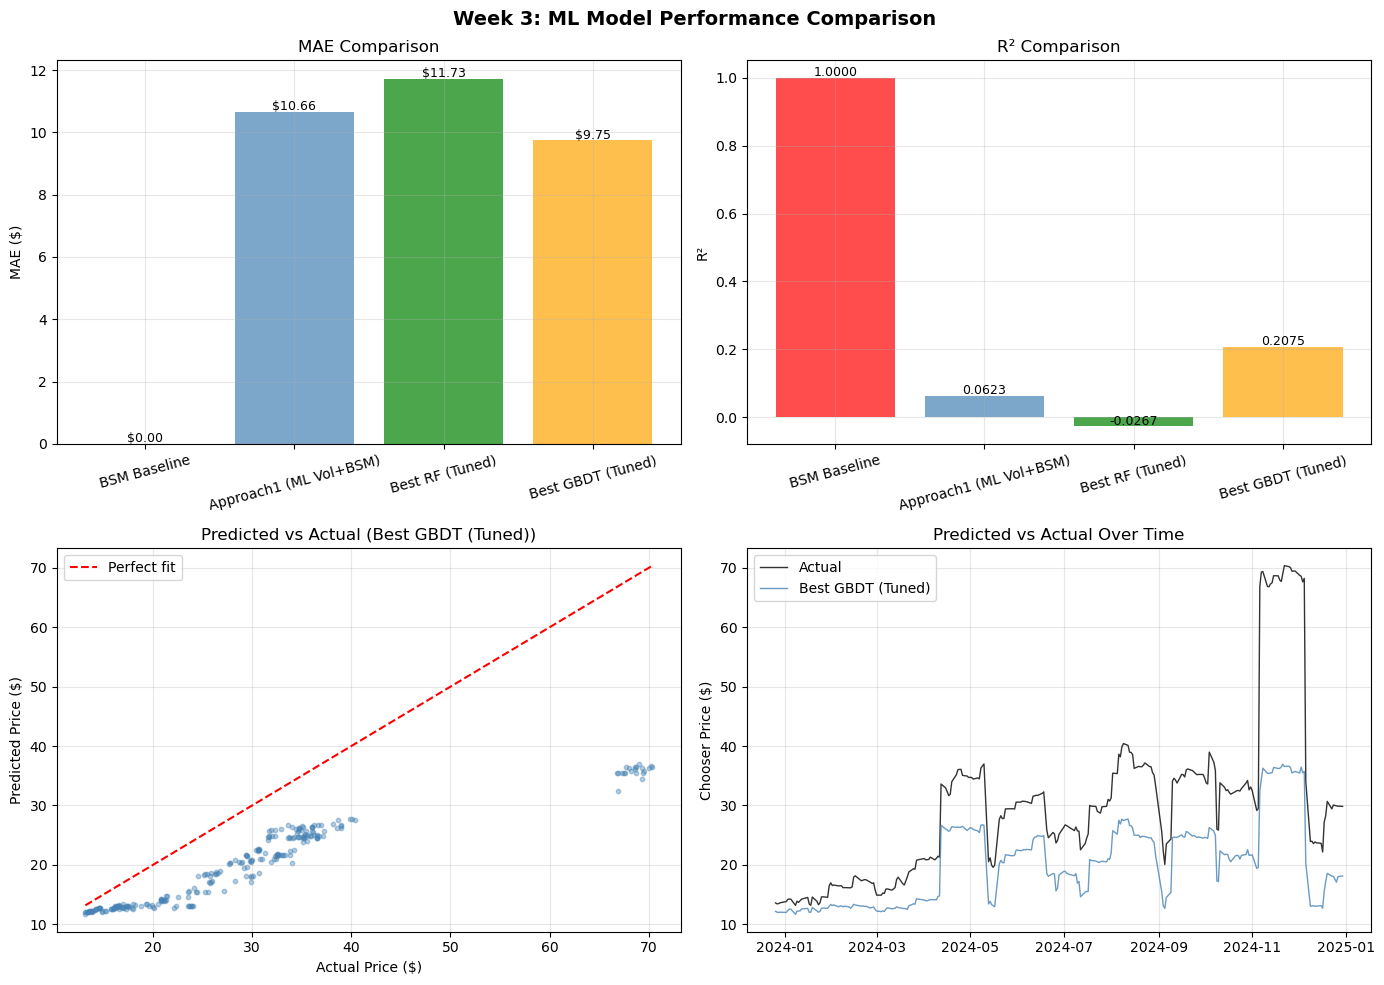

Performance visualization complete


In [11]:
#  Performance visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MAE comparison
names  = list(final_results.keys())
maes   = [final_results[n]["mae"] for n in names]
colors = ["red", "steelblue", "green", "orange"]
axes[0,0].bar(names, maes, color=colors, alpha=0.7)
axes[0,0].set_title("MAE Comparison")
axes[0,0].set_ylabel("MAE ($)")
axes[0,0].tick_params(axis="x", rotation=15)
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(maes):
    axes[0,0].text(i, v + 0.05, f"${v:.2f}", ha="center", fontsize=9)

# 2. R² comparison
r2s = [final_results[n]["r2"] for n in names]
axes[0,1].bar(names, r2s, color=colors, alpha=0.7)
axes[0,1].set_title("R² Comparison")
axes[0,1].set_ylabel("R²")
axes[0,1].tick_params(axis="x", rotation=15)
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(r2s):
    axes[0,1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

# 3. Predicted vs Actual (best non-BSM model)
best_model_name = min(
    [k for k in final_results if k != "BSM Baseline"],
    key=lambda x: final_results[x]["mae"]
)
best_pred = final_results[best_model_name]["pred"]
axes[1,0].scatter(y_test, best_pred, alpha=0.4, s=10, color="steelblue")
axes[1,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               "r--", lw=1.5, label="Perfect fit")
axes[1,0].set_title(f"Predicted vs Actual ({best_model_name})")
axes[1,0].set_xlabel("Actual Price ($)")
axes[1,0].set_ylabel("Predicted Price ($)")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Prediction over time
axes[1,1].plot(y_test.index, y_test.values,
               color="black", lw=1, label="Actual", alpha=0.8)
axes[1,1].plot(y_test.index, best_pred,
               color="steelblue", lw=1,
               label=best_model_name, alpha=0.8)
axes[1,1].set_title("Predicted vs Actual Over Time")
axes[1,1].set_ylabel("Chooser Price ($)")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Week 3: ML Model Performance Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("week3_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Performance visualization complete")

Feature Importance (SHAP):
                 SHAP_Importance
RealVol_30d             5.786556
JPM_Close               4.846845
Yield_3M                0.304607
Yield_2Y                0.150858
Yield_10Y               0.111577
VIX_JPM_Corr            0.099444
RealVol_60d             0.084018
Log_Return              0.073137
VIX_Close               0.071314
Sentiment_Score         0.053736
RealVol_10d             0.044323
Yield_Spread            0.038209
Rate_Momentum           0.014722
VIX_Regime_Code         0.000114


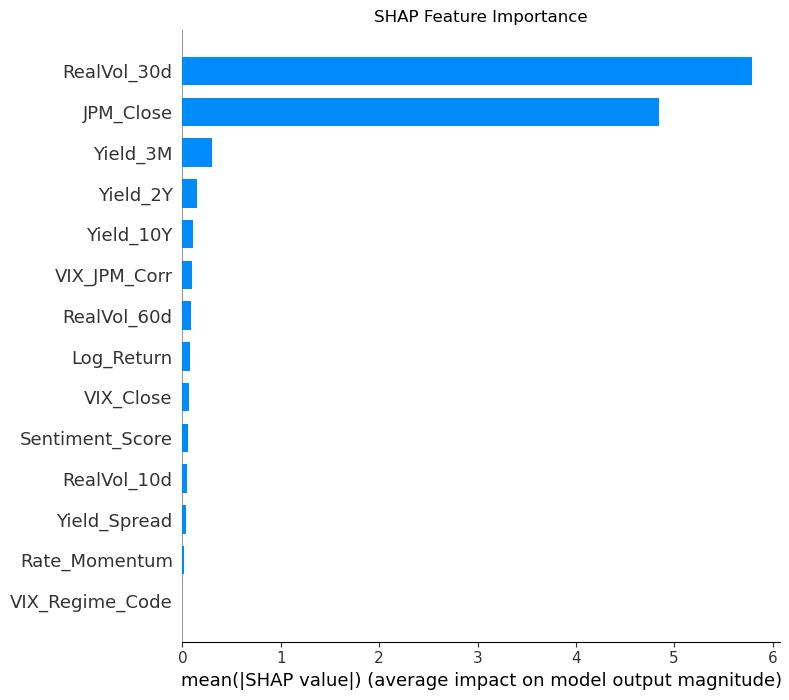

SHAP analysis complete


In [12]:
# SHAP feature importance analysis
import subprocess
subprocess.run(["pip", "install", "shap"], capture_output=True)
import shap

# Use best model between RF and GBDT
best_model = best_gbdt if final_results["Best GBDT (Tuned)"]["mae"] < \
             final_results["Best RF (Tuned)"]["mae"] else best_rf

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP importance table
shap_df = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols_final,
    columns=["SHAP_Importance"]
).sort_values("SHAP_Importance", ascending=False)

print("Feature Importance (SHAP):")
print(shap_df)

# SHAP bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_cols_final,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig("week3_shap.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP analysis complete")

In [13]:
# ============================================================
# Cell 14: Save models and report
# ============================================================
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/best_rf.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open("models/best_gbdt.pkl", "wb") as f:
    pickle.dump(best_gbdt, f)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save comparison report
report = pd.DataFrame({
    name: {
        "MAE":  round(res["mae"], 4),
        "RMSE": round(res["rmse"], 4),
        "R2":   round(res["r2"], 4),
    }
    for name, res in final_results.items()
}).T
report.to_csv("models/model_comparison_report.csv")

print("All models and reports saved")
print("  models/best_rf.pkl")
print("  models/best_gbdt.pkl")
print("  models/scaler.pkl")
print("  models/model_comparison_report.csv")
print(report)

All models and reports saved
  models/best_rf.pkl
  models/best_gbdt.pkl
  models/scaler.pkl
  models/model_comparison_report.csv
                            MAE     RMSE      R2
BSM Baseline             0.0000   0.0000  1.0000
Approach1 (ML Vol+BSM)  10.6596  13.4394  0.0623
Best RF (Tuned)         11.7256  14.0628 -0.0267
Best GBDT (Tuned)        9.7521  12.3548  0.2075


In [14]:
# Install XGBoost
import subprocess
subprocess.run(["pip", "install", "xgboost"], capture_output=True)
from xgboost import XGBRegressor

# Add XGBoost to models
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

val_pred_xgb  = xgb_model.predict(X_val_scaled)
test_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Results")
print(f"  Val  MAE : ${mean_absolute_error(y_val, val_pred_xgb):.4f}")
print(f"  Val  RMSE: ${np.sqrt(mean_squared_error(y_val, val_pred_xgb)):.4f}")
print(f"  Val  R²  : {r2_score(y_val, val_pred_xgb):.4f}")
print(f"  Test MAE : ${mean_absolute_error(y_test, test_pred_xgb):.4f}")
print(f"  Test RMSE: ${np.sqrt(mean_squared_error(y_test, test_pred_xgb)):.4f}")
print(f"  Test R²  : {r2_score(y_test, test_pred_xgb):.4f}")

XGBoost Results
  Val  MAE : $2.0027
  Val  RMSE: $2.3598
  Val  R²  : 0.7815
  Test MAE : $10.8263
  Test RMSE: $13.6498
  Test R²  : 0.0327


In [17]:
# week5
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import pickle
import shap
import warnings
warnings.filterwarnings("ignore")

# Load scaler and best model
with open("models/best_gbdt.pkl", "rb") as f:
    best_gbdt = pickle.load(f)

with open("models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Models loaded successfully")

Models loaded successfully


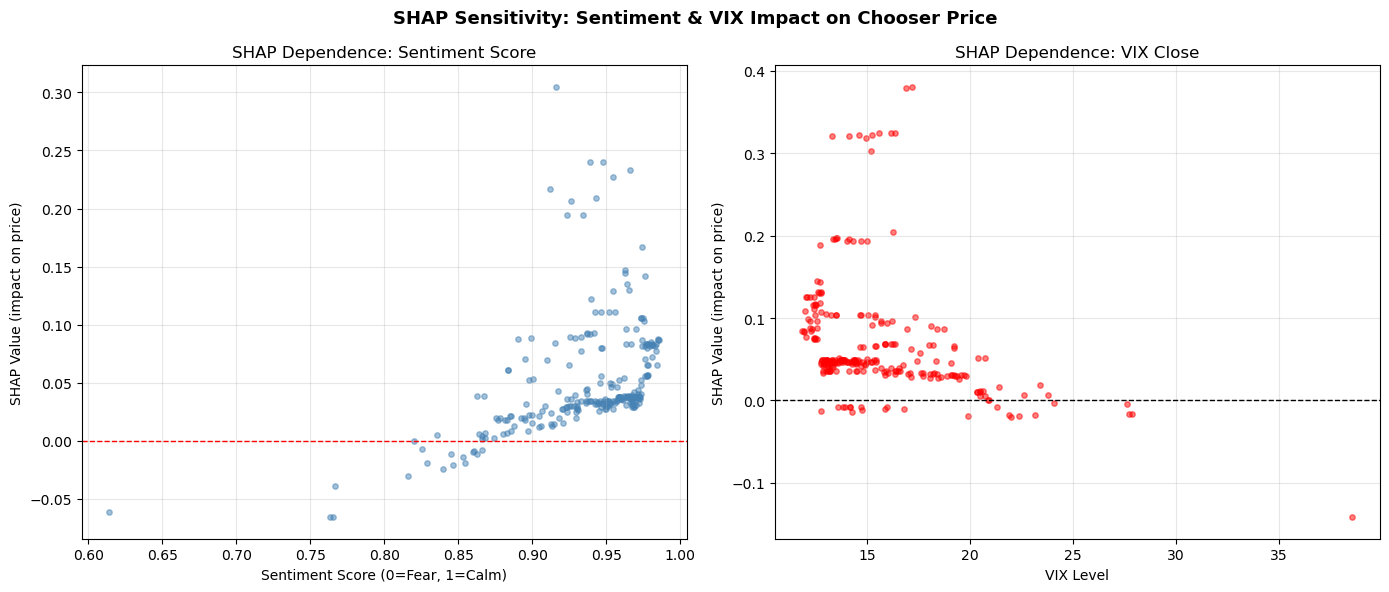

SHAP sensitivity analysis complete


In [21]:
# Test set only (last 15%)
n        = len(ml_df)
val_end  = int(n * 0.85)
X_test   = ml_df.iloc[val_end:][feature_cols_final]
X_test_scaled = scaler.transform(X_test)

# SHAP analysis
explainer   = shap.TreeExplainer(best_gbdt)
shap_values = explainer.shap_values(X_test_scaled)

# Focus on Sentiment and VIX
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sentiment Score SHAP dependence
sent_idx = feature_cols_final.index("Sentiment_Score")
axes[0].scatter(X_test["Sentiment_Score"],
                shap_values[:, sent_idx],
                alpha=0.5, color="steelblue", s=15)
axes[0].axhline(0, color="red", ls="--", lw=1)
axes[0].set_title("SHAP Dependence: Sentiment Score")
axes[0].set_xlabel("Sentiment Score (0=Fear, 1=Calm)")
axes[0].set_ylabel("SHAP Value (impact on price)")
axes[0].grid(True, alpha=0.3)

# VIX SHAP dependence
vix_idx = feature_cols_final.index("VIX_Close")
axes[1].scatter(X_test["VIX_Close"],
                shap_values[:, vix_idx],
                alpha=0.5, color="red", s=15)
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set_title("SHAP Dependence: VIX Close")
axes[1].set_xlabel("VIX Level")
axes[1].set_ylabel("SHAP Value (impact on price)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("SHAP Sensitivity: Sentiment & VIX Impact on Chooser Price",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("week7_shap_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP sensitivity analysis complete")

In [22]:
# Cell 3: BSM functions (needed for scenario testing)
def bsm_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bsm_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def chooser_option(S, K, T, tc, r, sigma):
    call  = bsm_call(S, K, T, r, sigma)
    K_adj = K * np.exp(-r*(T-tc))
    put   = bsm_put(S, K_adj, tc, r, sigma)
    return call + put, call, put

In [24]:
# ============================================================
# Cell 5: Extreme scenario testing
# Scenario 1: Volatility spike +50%
# Scenario 2: Rate hike +2%
# Scenario 3: Both combined (worst case)
# ============================================================
# Use latest market data as base
base = df.iloc[-1]
S_base     = base["JPM_Close"]
r_base     = base["Yield_3M"] / 100
sigma_base = base["RealVol_30d"]

print("=" * 55)
print("  Extreme Scenario Testing")
print("=" * 55)
print(f"\n  Base Parameters:")
print(f"  JPM Price (S)    : ${S_base:.2f}")
print(f"  Risk-free Rate   : {r_base*100:.2f}%")
print(f"  Realized Vol     : {sigma_base*100:.2f}%")

  Extreme Scenario Testing

  Base Parameters:
  JPM Price (S)    : $231.08
  Risk-free Rate   : 4.37%
  Realized Vol     : 18.68%


In [25]:
# Base price
base_price, base_call, base_put = chooser_option(
    S_base, S_base, 1.0, 0.5, r_base, sigma_base)

# Scenario 1: Vol spike +50%
sigma_spike = sigma_base * 1.5
price_vol, _, _ = chooser_option(
    S_base, S_base, 1.0, 0.5, r_base, sigma_spike)

# Scenario 2: Rate hike +2%
r_hike = r_base + 0.02
price_rate, _, _ = chooser_option(
    S_base, S_base, 1.0, 0.5, r_hike, sigma_base)

# Scenario 3: Both combined
price_both, _, _ = chooser_option(
    S_base, S_base, 1.0, 0.5, r_hike, sigma_spike)

print(f"\n  Scenario Results:")
print(f"  {'Scenario':<30} {'Price':>8} {'Change':>10} {'Change%':>10}")
print(f"  {'-'*58}")
print(f"  {'Base Case':<30} ${base_price:>7.4f} {'—':>10} {'—':>10}")
print(f"  {'Vol Spike +50%':<30} ${price_vol:>7.4f} "
      f"${price_vol-base_price:>+9.4f} "
      f"{(price_vol-base_price)/base_price*100:>+9.2f}%")
print(f"  {'Rate Hike +2%':<30} ${price_rate:>7.4f} "
      f"${price_rate-base_price:>+9.4f} "
      f"{(price_rate-base_price)/base_price*100:>+9.2f}%")
print(f"  {'Vol Spike + Rate Hike':<30} ${price_both:>7.4f} "
      f"${price_both-base_price:>+9.4f} "
      f"{(price_both-base_price)/base_price*100:>+9.2f}%")
print(f"  {'='*58}")


  Scenario Results:
  Scenario                          Price     Change    Change%
  ----------------------------------------------------------
  Base Case                      $29.8370          —          —
  Vol Spike +50%                 $43.7756 $ +13.9386    +46.72%
  Rate Hike +2%                  $30.7563 $  +0.9193     +3.08%
  Vol Spike + Rate Hike          $44.1640 $ +14.3270    +48.02%


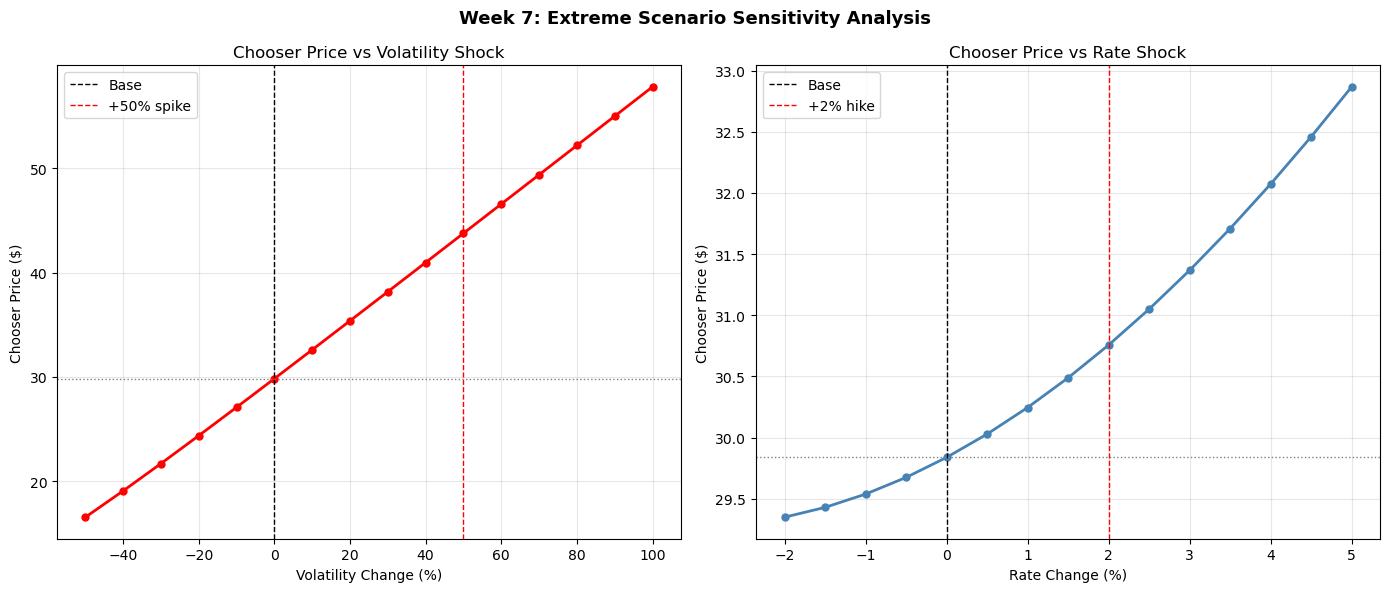

Scenario visualization complete


In [26]:
# Cell 6: Scenario visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Vol spike sensitivity curve
vol_range    = np.arange(0.5, 2.1, 0.1)
prices_vol   = [chooser_option(S_base, S_base, 1.0, 0.5, r_base,
                                sigma_base*v)[0] for v in vol_range]
axes[0].plot(vol_range*100 - 100, prices_vol,
             color="red", lw=2, marker="o", markersize=5)
axes[0].axvline(0,  color="black", ls="--", lw=1, label="Base")
axes[0].axvline(50, color="red",   ls="--", lw=1, label="+50% spike")
axes[0].axhline(base_price, color="gray", ls=":", lw=1)
axes[0].set_title("Chooser Price vs Volatility Shock")
axes[0].set_xlabel("Volatility Change (%)")
axes[0].set_ylabel("Chooser Price ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Rate hike sensitivity curve
rate_range   = np.arange(-0.02, 0.051, 0.005)
prices_rate  = [chooser_option(S_base, S_base, 1.0, 0.5,
                                r_base+dr, sigma_base)[0] for dr in rate_range]
axes[1].plot(rate_range*100, prices_rate,
             color="steelblue", lw=2, marker="o", markersize=5)
axes[1].axvline(0,  color="black", ls="--", lw=1, label="Base")
axes[1].axvline(2,  color="red",   ls="--", lw=1, label="+2% hike")
axes[1].axhline(base_price, color="gray", ls=":", lw=1)
axes[1].set_title("Chooser Price vs Rate Shock")
axes[1].set_xlabel("Rate Change (%)")
axes[1].set_ylabel("Chooser Price ($)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Week 7: Extreme Scenario Sensitivity Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("week7_scenario.png", dpi=150, bbox_inches="tight")
plt.show()
print("Scenario visualization complete")

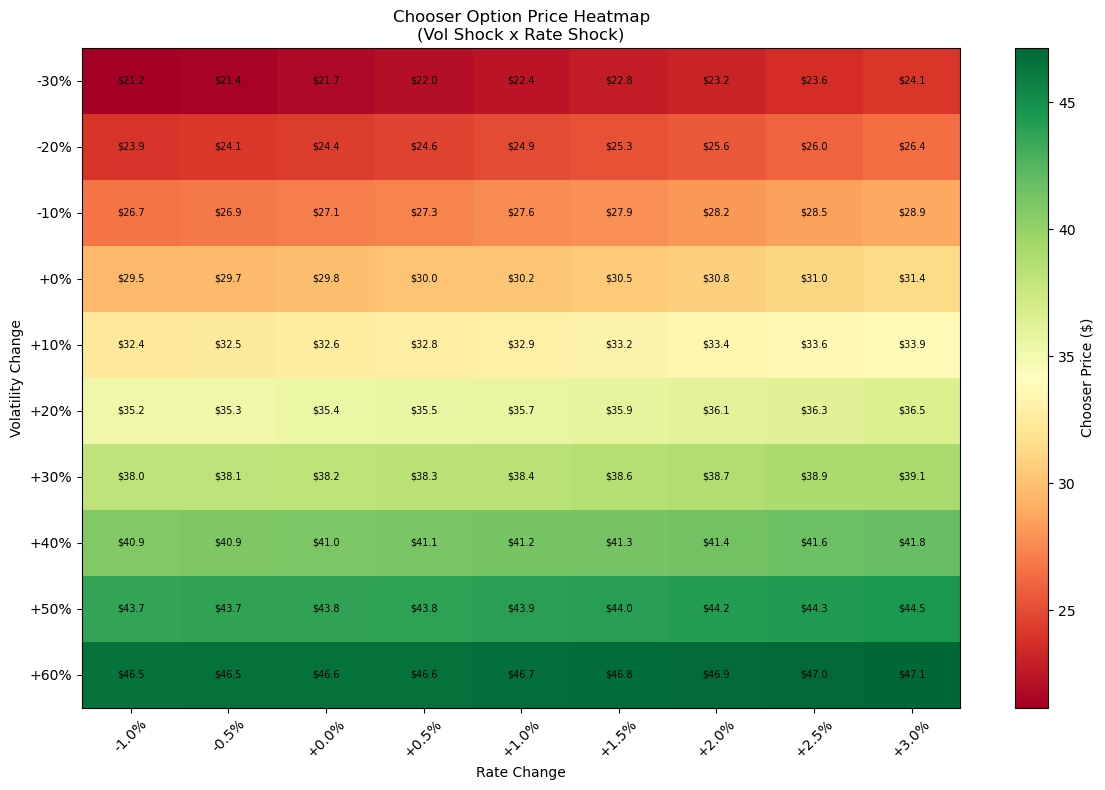

Heatmap complete


In [27]:
# ============================================================
# Cell 7: Scenario heatmap (Vol x Rate combined)
# ============================================================
vol_changes  = np.arange(-0.3, 0.61, 0.1)
rate_changes = np.arange(-0.01, 0.031, 0.005)

price_matrix = np.zeros((len(vol_changes), len(rate_changes)))
for i, dv in enumerate(vol_changes):
    for j, dr in enumerate(rate_changes):
        sigma_new = max(sigma_base * (1 + dv), 0.01)
        r_new     = r_base + dr
        price_matrix[i, j] = chooser_option(
            S_base, S_base, 1.0, 0.5, r_new, sigma_new)[0]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(price_matrix, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(rate_changes)))
ax.set_yticks(range(len(vol_changes)))
ax.set_xticklabels([f"{r*100:+.1f}%" for r in rate_changes], rotation=45)
ax.set_yticklabels([f"{v*100:+.0f}%" for v in vol_changes])
ax.set_xlabel("Rate Change")
ax.set_ylabel("Volatility Change")
ax.set_title("Chooser Option Price Heatmap\n(Vol Shock x Rate Shock)")
plt.colorbar(im, ax=ax, label="Chooser Price ($)")

# Annotate cells
for i in range(len(vol_changes)):
    for j in range(len(rate_changes)):
        ax.text(j, i, f"${price_matrix[i,j]:.1f}",
                ha="center", va="center", fontsize=7,
                color="black")

plt.tight_layout()
plt.savefig("week7_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap complete")

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv(r"C:\Users\sasa0\Desktop\Chooser_option\data\featured_dataset.csv",
                 index_col=0, parse_dates=True)
results_df = pd.read_csv(r"C:\Users\sasa0\Desktop\Chooser_option\data\bsm_results.csv",
                         index_col=0, parse_dates=True)

# Add sentiment
df["Sentiment_Score"] = 1 - (df["VIX_Close"] - df["VIX_Close"].min()) / (
    df["VIX_Close"].max() - df["VIX_Close"].min())

# Features
feature_cols = [
    "JPM_Close", "VIX_Close", "Yield_3M", "Yield_2Y", "Yield_10Y",
    "Log_Return", "RealVol_10d", "RealVol_30d", "RealVol_60d",
    "Rate_Momentum", "Yield_Spread", "VIX_JPM_Corr", "Sentiment_Score",
]
feature_cols = [c for c in feature_cols if c in df.columns]

ml_df = results_df[["Chooser_Price"]].join(df[feature_cols], how="inner")
ml_df["VIX_Regime_Code"] = df["VIX_Regime"].map({"Low":0,"Medium":1,"High":2})
feature_cols.append("VIX_Regime_Code")
ml_df = ml_df.dropna()

n = len(ml_df)
train_end = int(n * 0.70)
train = ml_df.iloc[:train_end]
feature_cols_final = [c for c in ml_df.columns if c != "Chooser_Price"]

X_train = train[feature_cols_final]
y_train = train["Chooser_Price"]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Retrain GBDT with best params
best_gbdt = GradientBoostingRegressor(
    learning_rate=0.1, max_depth=3, n_estimators=200, random_state=42)
best_gbdt.fit(X_train_scaled, y_train)

# Retrain RF with best params
best_rf = RandomForestRegressor(
    max_depth=20, min_samples_split=2, n_estimators=50, random_state=42)
best_rf.fit(X_train_scaled, y_train)

# Save
import os
os.makedirs(r"C:\Users\sasa0\Desktop\Chooser_option\week3\models", exist_ok=True)

with open(r"C:\Users\sasa0\Desktop\Chooser_option\week3\models\best_gbdt.pkl", "wb") as f:
    pickle.dump(best_gbdt, f)
with open(r"C:\Users\sasa0\Desktop\Chooser_option\week3\models\best_rf.pkl", "wb") as f:
    pickle.dump(best_rf, f)
with open(r"C:\Users\sasa0\Desktop\Chooser_option\week3\models\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Models retrained and saved successfully")
print(f"scikit-learn version: {__import__('sklearn').__version__}")

Models retrained and saved successfully
scikit-learn version: 1.6.1


In [2]:
import sys
import sklearn
import numpy
import scipy
import pandas

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pandas.__version__)

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.6.1
numpy: 2.1.3
scipy: 1.15.3
pandas: 2.2.3
